# 01 — Vertical reference concepts: geoid, ellipsoid, and RAF20

This notebook introduces the **vertical reference concepts** needed before converting DEM elevations for the workflow.

It explains:

- what the **ellipsoid** is,
- what the **geoid / quasi-geoid** represents,
- the difference between **ellipsoidal height** and **physical height**,
- why **ASP requires ellipsoidal heights** for the reference DEM,
- and how **RAF20** is used in mainland France.

> **Important note**  
> The explanations below follow standard geodetic concepts and the commonly used French practice of converting between **NGF-IGN69 heights** and **RGF93 ellipsoidal heights** using **RAF20**.  

---

## Main references

1. **IGN Géodésie** — official French geodetic reference information and conversion grids (including RAF20):  
   https://geodesie.ign.fr/

2. **IGN conversion grids / geodetic products** — information on French transformation grids and vertical reference material:  
   https://geodesie.ign.fr/grilles-de-conversion

3. **Ames Stereo Pipeline documentation** — reference DEM heights should be in an ellipsoidal vertical reference when used in stereophotogrammetric processing:  
   https://stereopipeline.readthedocs.io/

4. Hofmann-Wellenhof, B., & Moritz, H. (2006). *Physical Geodesy* (2nd ed.). Springer.

5. Torge, W., & Müller, J. (2012). *Geodesy* (4th ed.). de Gruyter.

---

## 1. Why this notebook matters for the workflow

In this workflow, the reference DEM is used during preprocessing and map projection.  
For these steps, the elevations must be expressed in a vertical reference that is consistent with the satellite geometry, which is typically the **ellipsoid**.

Many topographic datasets, however, are distributed in a **physical height system** rather than in ellipsoidal height.  
In France, LiDAR products are often referenced to **NGF-IGN69**, while satellite processing generally expects elevations relative to the **reference ellipsoid** associated with the geodetic datum.

Therefore, before using the DEM in the workflow, we may need to convert the heights from **NGF-IGN69** to **ellipsoidal heights**.  
For mainland France, this conversion is commonly performed using the **RAF20** model from IGN.

**Reference:** IGN Géodésie; Ames Stereo Pipeline documentation.

## 2. Core concepts

### 2.1 The ellipsoid

The **ellipsoid** is a smooth mathematical surface that approximates the shape of the Earth.  
It is simple, continuous, and easy to use in positioning, mapping, and satellite geometry.

A GNSS receiver naturally gives positions relative to an ellipsoid.  
In France and much of Europe, the geodetic reference frame is linked to the **GRS80 ellipsoid** through the **RGF93** datum family.

### 2.2 The geoid (or quasi-geoid in practical height systems)

The **geoid** is an equipotential surface of the Earth's gravity field that approximates mean sea level.  
Unlike the ellipsoid, it is not a simple mathematical shape: it is irregular because Earth's gravity field is irregular.

In practical mapping, height systems based on levelling are often connected to the geoid or quasi-geoid.  
In France, a commonly used physical height reference is **NGF-IGN69**.

### 2.3 Two different types of height

At one point on the Earth's surface, we commonly distinguish:

- **Ellipsoidal height**: \(h\)  
  Height measured above the reference ellipsoid.

- **Orthometric or normal height** (practical physical height): \(H\)  
  Height measured relative to a physical reference surface connected to mean sea level.

- **Geoid / quasi-geoid separation**: \(N\) or \(\zeta\)  
  The vertical separation between the ellipsoid and the geoid / quasi-geoid reference surface.

The standard relationship is:

\[
h = H + N
\]

or, depending on the convention used for the vertical model in the documentation,

\[
h = H + \zeta
\]

The exact symbol may differ between references, but the core idea is the same:  
**ellipsoidal height = physical height + vertical separation model**.

**Reference:** Hofmann-Wellenhof & Moritz (2006); Torge & Müller (2012); IGN Géodésie.

In [1]:
# Simple text summary of the main equations

print("Main height relationship:")
print("    h = H + N")
print()
print("where:")
print("    h = ellipsoidal height")
print("    H = physical height (e.g. NGF-IGN69)")
print("    N = geoid/quasi-geoid separation")

Main height relationship:
    h = H + N

where:
    h = ellipsoidal height
    H = physical height (e.g. NGF-IGN69)
    N = geoid/quasi-geoid separation


## 3. Conceptual figure: ellipsoid, geoid, and heights

The figure below is a **schematic illustration**.  
It is not to scale.  
It only aims to explain the geometric meaning of:

- the **ellipsoid**,
- the **geoid/quasi-geoid**,
- the **terrain point**,
- the **ellipsoidal height** \(h\),
- the **physical height** \(H\),
- and the **separation** \(N\).

You can keep this figure in the notebook as an educational diagram.

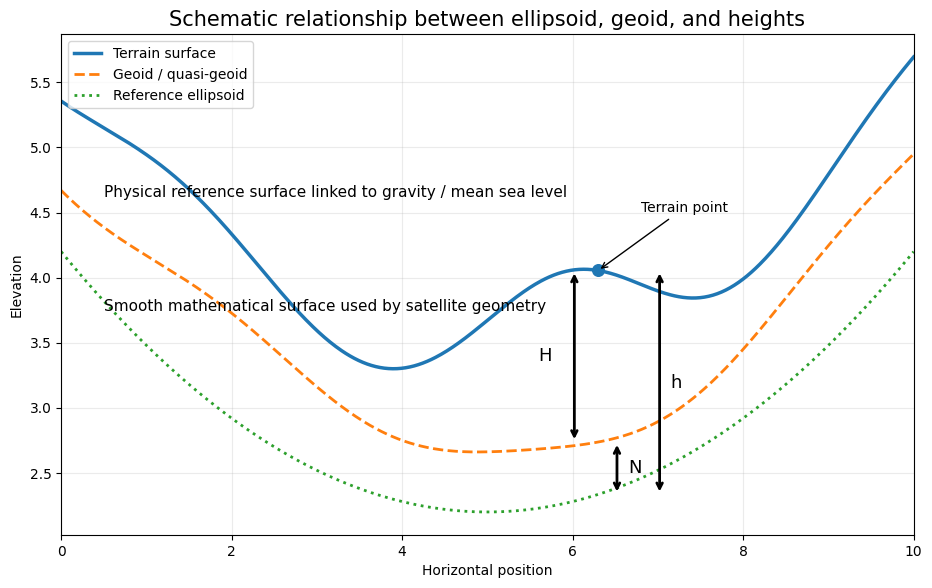

In [2]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 600)

# Schematic surfaces
ellipsoid = 2.2 + 0.08*(x - 5)**2
geoid = ellipsoid + 0.55 + 0.18*np.sin(0.8*x) - 0.08*np.cos(1.7*x)
terrain = geoid + 0.6 + 0.6*np.exp(-0.5*(x-6.2)**2) + 0.18*np.sin(1.3*x + 0.5)

fig, ax = plt.subplots(figsize=(11, 6.5))

ax.plot(x, terrain, linewidth=2.5, label="Terrain surface")
ax.plot(x, geoid, linewidth=2.0, linestyle="--", label="Geoid / quasi-geoid")
ax.plot(x, ellipsoid, linewidth=2.0, linestyle=":", label="Reference ellipsoid")

xp = 6.3
y_ell = np.interp(xp, x, ellipsoid)
y_geo = np.interp(xp, x, geoid)
y_ter = np.interp(xp, x, terrain)

ax.scatter([xp], [y_ter], s=70)
ax.annotate("Terrain point", (xp, y_ter), xytext=(xp+0.5, y_ter+0.45),
            arrowprops=dict(arrowstyle="->"))

# H
ax.annotate("", xy=(xp-0.28, y_ter), xytext=(xp-0.28, y_geo),
            arrowprops=dict(arrowstyle="<->", linewidth=2))
ax.text(xp-0.7, (y_ter+y_geo)/2, "H", fontsize=13, va="center")

# N
ax.annotate("", xy=(xp+0.22, y_geo), xytext=(xp+0.22, y_ell),
            arrowprops=dict(arrowstyle="<->", linewidth=2))
ax.text(xp+0.35, (y_geo+y_ell)/2, "N", fontsize=13, va="center")

# h
ax.annotate("", xy=(xp+0.72, y_ter), xytext=(xp+0.72, y_ell),
            arrowprops=dict(arrowstyle="<->", linewidth=2))
ax.text(xp+0.85, (y_ter+y_ell)/2, "h", fontsize=13, va="center")

ax.text(0.5, ellipsoid[20]-0.2, "Smooth mathematical surface used by satellite geometry", fontsize=11)
ax.text(0.5, geoid[20]+0.15, "Physical reference surface linked to gravity / mean sea level", fontsize=11)

ax.set_title("Schematic relationship between ellipsoid, geoid, and heights", fontsize=15)
ax.set_xlabel("Horizontal position")
ax.set_ylabel("Elevation")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.25)
ax.set_xlim(0, 10)

plt.show()

### Interpretation of the figure

At the selected terrain point:

- \(H\) is the height above the geoid / quasi-geoid reference surface.
- \(N\) is the separation between the geoid / quasi-geoid and the ellipsoid.
- \(h\) is the height above the ellipsoid.

This is why the relationship is:

\[
h = H + N
\]

In practical terms, if your LiDAR DEM is in a physical height system and your processing tool expects ellipsoidal height, you must add the vertical separation model.

**Reference:** standard geodetic height definitions in geodesy textbooks and IGN documentation.

## 4. Why RAF20 is relevant in France

For mainland France, IGN provides **RAF20**, which is used as the vertical separation model for converting between a French physical height reference and ellipsoidal height in the RGF93 framework.

In practice for your workflow:

- **Input DEM** may be in **NGF-IGN69**,
- **Target DEM** for ASP should be in **ellipsoidal height**,
- **Conversion model** is **RAF20**.

In other words, RAF20 supplies the spatially varying correction needed to move between these two vertical references.

A key point is that this correction is **not constant** over France.  
Therefore, the conversion should never be done using a single fixed offset for the whole DEM.

**Reference:** IGN Géodésie and RAF20 documentation.

## 5. France-specific conceptual chain used in this workflow

For the workflow, the conceptual chain is:

1. Start from a DEM with heights in **NGF-IGN69**.
2. Use **RAF20** to compute the local separation value.
3. Convert the DEM elevations to **ellipsoidal height**.
4. Use this ellipsoidal DEM in the ASP preprocessing / map projection workflow.

The reverse operation is also possible:

- if a DEM is already in ellipsoidal height and you want a product in NGF-IGN69,
- then the RAF20 correction is applied in the opposite direction.

The simplified relationships are:

### NGF-IGN69 to ellipsoidal height

\[
h_{ellipsoid} = H_{NGF-IGN69} + N_{RAF20}
\]

### Ellipsoidal height to NGF-IGN69

\[
H_{NGF-IGN69} = h_{ellipsoid} - N_{RAF20}
\]

> The sign convention should always be checked against the exact documentation and software implementation used in the conversion code.

**Reference:** IGN official vertical transformation material and standard geodetic equations.

In [3]:
# Optional illustrative example with a hypothetical local separation value

H_ngf = 1543.27   # example physical height in metres
N_raf20 = 47.18   # example local RAF20 separation in metres

h_ell = H_ngf + N_raf20
H_back = h_ell - N_raf20

print(f"Example NGF-IGN69 height H = {H_ngf:.2f} m")
print(f"Example RAF20 separation N = {N_raf20:.2f} m")
print(f"Converted ellipsoidal height h = H + N = {h_ell:.2f} m")
print(f"Back-converted physical height H = h - N = {H_back:.2f} m")

Example NGF-IGN69 height H = 1543.27 m
Example RAF20 separation N = 47.18 m
Converted ellipsoidal height h = H + N = 1590.45 m
Back-converted physical height H = h - N = 1543.27 m


## 6. Why the reference DEM for ASP should be ellipsoidal

Satellite image orientation and RPC-based geometry are tied to a geodetic reference frame and ellipsoidal coordinates.  
When a reference DEM is introduced during map projection or geometric correction, it is safest and most consistent to use elevations expressed relative to the ellipsoid.

If a DEM referenced to a physical height system is used directly without conversion, the resulting height inconsistency can propagate into the projected geometry and lead to vertical or planimetric inconsistencies.

This is why the workflow converts the DEM to ellipsoidal height before using it in ASP.

**Reference:** Ames Stereo Pipeline documentation and standard photogrammetric practice.

## 7. Practical notes for the GitHub repository

In the GitHub workflow, it is useful to keep the following distinctions explicit:

- **Horizontal CRS**: for example, Lambert-93 / RGF93
- **Vertical reference**: for example, NGF-IGN69 or ellipsoidal height
- **Conversion model**: RAF20
- **Conversion direction**:
  - `ngf69_to_ellipsoid`
  - `ellipsoid_to_ngf69`

This avoids ambiguity because the horizontal CRS alone does **not** fully describe the vertical reference of the raster values.

Recommended documentation points for the repository:

1. State the original vertical reference of the DEM.
2. State the target vertical reference required by the workflow.
3. Name the conversion model explicitly: **RAF20**.
4. Document the equation used.
5. Keep the conversion as a dedicated notebook / script in the repository.

**Reference:** good reproducibility practice in geospatial workflows.

## 8. Suggested figure captions if you export the plots

### Figure 1
**Schematic relationship between the ellipsoid, the geoid/quasi-geoid, and the terrain surface.**  
The diagram illustrates the physical height \(H\), the ellipsoidal height \(h\), and the geoid/quasi-geoid separation \(N\), with the standard relationship \(h = H + N\).

### Figure 2
**Conceptual role of RAF20 in mainland France.**  
RAF20 provides the spatially varying vertical separation used to convert between NGF-IGN69 physical heights and RGF93 ellipsoidal heights.

You may reuse or adapt these captions later in the README or manuscript support material.

## 9. Short summary

This notebook introduces the key concepts needed for vertical-reference conversion in the workflow.

The essential points are:

- the **ellipsoid** is the mathematical surface used by geodetic and satellite geometry,
- the **geoid/quasi-geoid** is the physical reference surface linked to gravity,
- **ellipsoidal height** and **physical height** are different quantities,
- their relationship is described through a **vertical separation model**,
- and in mainland France this conversion is commonly handled using **RAF20**.

For the workflow, the practical objective is simple:  
**convert the DEM to ellipsoidal height before using it in ASP**.

---

## 10. References

- IGN Géodésie. Official French geodetic information portal.  
  https://geodesie.ign.fr/

- IGN — Grilles de conversion / transformation products.  
  https://geodesie.ign.fr/grilles-de-conversion

- Ames Stereo Pipeline Documentation.  
  https://stereopipeline.readthedocs.io/

- Hofmann-Wellenhof, B., & Moritz, H. (2006). *Physical Geodesy* (2nd ed.). Springer.

- Torge, W., & Müller, J. (2012). *Geodesy* (4th ed.). de Gruyter.